# 1. Import Libraries

In [1]:
import os
import sys
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime

# 2. File Paths

In [2]:
scripts_path = os.path.abspath(os.path.join('..', 'Scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

data_dir = os.path.abspath(os.path.join('..', 'Data', 'TrainTest'))
hyperparameter_dir = os.path.abspath(os.path.join('..', 'Data', 'HyperParameters'))
save_dir = os.path.abspath(os.path.join('..', 'Data', 'SavedModels'))
loss_history_dir = os.path.abspath(os.path.join('..', 'Data','LossHistory'))
visualization_dir = os.path.abspath(os.path.join('..', 'Data','Visualization'))

# 3. Load Models & Data

## 1. Data

In [3]:
train_data = np.load(os.path.join(data_dir, 'train_data.npy')).astype(np.float32)
num_items = train_data.shape[1]

## 2. Models

In [4]:
from model import Encoder, Decoder, VAE, RSVD

# 4. Training

## 1. VAE

### 1. Import Hyperparameters

In [5]:
vae_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_vae.json')
with open(vae_progress_file, 'r') as f:
    best_vae_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang VAE dengan parameter terbaik: {best_vae_params}")


[INFO] Melatih ulang VAE dengan parameter terbaik: {'latent_dim': 10, 'learning_rate': 0.005, 'batch_size': 64, 'dropout_rate': 0.5, 'hidden_dims': [256, 128]}


### 2. Construct Model

In [6]:
encoder = Encoder(hidden_dims=best_vae_params['hidden_dims'], latent_dim=best_vae_params['latent_dim'], dropout_rate=best_vae_params['dropout_rate'])
decoder = Decoder(hidden_dims=best_vae_params['hidden_dims'][::-1], output_dim=num_items)
final_vae = VAE(encoder, decoder)

_ = final_vae(train_data[:1]) 
optimizer = tf.keras.optimizers.Adam(learning_rate=best_vae_params['learning_rate'])
final_vae.compile(optimizer=optimizer)

# Fitur Early Stopping: Berhenti jika loss tidak membaik selama 10 epoch berturut-turut
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss', patience=10, restore_best_weights=True, verbose=1
)

### 3. Training Model

In [7]:
history = final_vae.fit(
    train_data, train_data, 
    epochs=200,
    batch_size=best_vae_params['batch_size'], 
    callbacks=[early_stopping],
    verbose=1 # Tampilkan progress bar agar kita tahu pergerakannya
)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 2.4783 - loss: 90.1352 - reconstruction_loss: 89.6395  
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 0.7585 - loss: 71.3735 - reconstruction_loss: 71.2218
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 2.0782 - loss: 70.9873 - reconstruction_loss: 70.5716
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 3.3844 - loss: 68.4133 - reconstruction_loss: 67.7365
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 5.2974 - loss: 64.7925 - reconstruction_loss: 63.7330
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 5.5617 - loss: 62.1516 - reconstruction_loss: 61.0393
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 6.9621 - loss: 59.2796 - reconstruction_loss: 57.8871
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 6.7565 - loss: 57.3550 - reconstruction_loss: 56.0037
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 7.8521 -

### 4. Save Weights
    Save model weights after finished training

In [8]:
final_vae.save_weights(os.path.join(save_dir, 'trained_best_vae_weights.weights.h5'))
print("[SUCCESS] Bobot VAE Final berhasil disimpan!")

[SUCCESS] Bobot VAE Final berhasil disimpan!


### 5. Save Loss History
    Save loss history for visualization later

In [9]:
vae_history_dict = {'loss': history.history['loss']}

with open(os.path.join(loss_history_dir, 'final_vae_loss_history.json'), 'w') as f:
    json.dump(vae_history_dict, f)

### 6. Latent Matrix Z
    Get latent matrix from VAE for training RSVD

In [10]:
print("\n[INFO] Mengekstrak Matriks Laten Z Final...")
z_mean, _ = final_vae.encoder.predict(train_data, batch_size=best_vae_params['batch_size'])
latent_matrix_Z_final = z_mean


[INFO] Mengekstrak Matriks Laten Z Final...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


## 2. RSVD

### 1. Import Hyperparameters

In [11]:
rsvd_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_rsvd.json')
with open(rsvd_progress_file, 'r') as f:
    best_rsvd_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang RSVD dengan parameter terbaik: {best_rsvd_params}")


[INFO] Melatih ulang RSVD dengan parameter terbaik: {'n_factors': 10, 'learning_rate': 0.02, 'lambda_reg': 0.001}


### 2. Construct Model

In [12]:
final_rsvd = RSVD(
    n_factors=best_rsvd_params['n_factors'], 
    learning_rate=best_rsvd_params['learning_rate'], 
    lambda_reg=best_rsvd_params['lambda_reg'], 
    epochs=100 # Naik drastis agar dekomposisi sempurna
)

### 3. Training Model

In [13]:
final_rsvd.fit(latent_matrix_Z_final)

Epoch 001/100 | Training MSE: 1.168449
Epoch 002/100 | Training MSE: 1.168339
Epoch 003/100 | Training MSE: 1.168208
Epoch 004/100 | Training MSE: 1.168003
Epoch 005/100 | Training MSE: 1.167632
Epoch 006/100 | Training MSE: 1.166885
Epoch 007/100 | Training MSE: 1.165191
Epoch 008/100 | Training MSE: 1.160657
Epoch 009/100 | Training MSE: 1.146150
Epoch 010/100 | Training MSE: 1.100773
Epoch 011/100 | Training MSE: 0.992261
Epoch 012/100 | Training MSE: 0.817158
Epoch 013/100 | Training MSE: 0.673940
Epoch 014/100 | Training MSE: 0.564702
Epoch 015/100 | Training MSE: 0.446137
Epoch 016/100 | Training MSE: 0.401742
Epoch 017/100 | Training MSE: 0.383831
Epoch 018/100 | Training MSE: 0.353965
Epoch 019/100 | Training MSE: 0.303229
Epoch 020/100 | Training MSE: 0.253729
Epoch 021/100 | Training MSE: 0.204764
Epoch 022/100 | Training MSE: 0.187979
Epoch 023/100 | Training MSE: 0.176159
Epoch 024/100 | Training MSE: 0.142936
Epoch 025/100 | Training MSE: 0.086534
Epoch 026/100 | Training 

### 4. Save Weights

In [14]:
np.save(os.path.join(save_dir, 'best_U.npy'), final_rsvd.U)
np.save(os.path.join(save_dir, 'best_Sigma.npy'), final_rsvd.Sigma)
np.save(os.path.join(save_dir, 'best_V.npy'), final_rsvd.V)
print("[SUCCESS] Matriks RSVD Final berhasil disimpan!")

[SUCCESS] Matriks RSVD Final berhasil disimpan!


### 5. Save Loss History
    Save loss history for visualization later

In [15]:
np.save(os.path.join(loss_history_dir, 'final_rsvd_loss_history.npy'), final_rsvd.loss_history)

# 5. Training Visualization

## 1. Import Loss History

### 1. VAE

In [16]:
try:
    # Load History Data from Hard Drive
    with open(os.path.join(loss_history_dir, 'final_vae_loss_history.json'), 'r') as f:
        vae_loss_history = json.load(f)['loss']

except FileNotFoundError as e:
    print(f"[ERROR] Could not find the history files. Details: {e}")

### 2. RSVD

In [17]:
rsvd_loss_history = np.load(os.path.join(loss_history_dir, 'final_rsvd_loss_history.npy'))

## 2. Visualization

[SUCCESS] High-resolution plot saved at: c:\Users\Basudewa\Documents\Mata Kuliah\Ujian Proposal\Programs\Data\Visualization\final_training_curves_20260305_2145.png


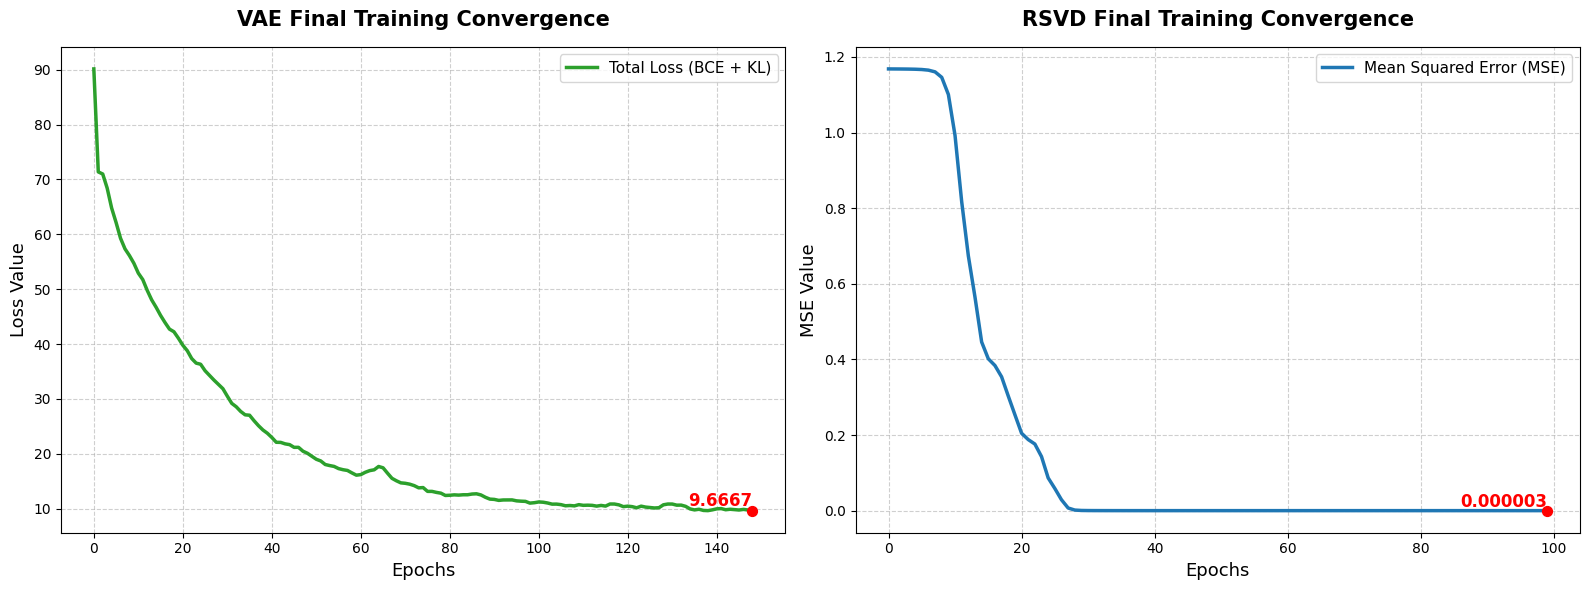

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
    
# ==========================================
# PLOT 1: VAE LOSS CURVE
# ==========================================
ax1 = axes[0]
ax1.plot(vae_loss_history, label='Total Loss (BCE + KL)', color='#2ca02c', linewidth=2.5)

# Highlight the final epoch
vae_final_epoch = len(vae_loss_history) - 1
vae_final_loss = vae_loss_history[-1]
ax1.scatter(vae_final_epoch, vae_final_loss, color='red', s=50, zorder=5)
ax1.text(vae_final_epoch, vae_final_loss + (vae_final_loss * 0.02), f'{vae_final_loss:.4f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax1.set_title('VAE Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=13)
ax1.set_ylabel('Loss Value', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right', fontsize=11)
# ==========================================
# PLOT 2: RSVD MSE CURVE
# ==========================================
ax2 = axes[1]
ax2.plot(rsvd_loss_history, label='Mean Squared Error (MSE)', color='#1f77b4', linewidth=2.5)

# Highlight the final epoch
rsvd_final_epoch = len(rsvd_loss_history) - 1
rsvd_final_loss = rsvd_loss_history[-1]
ax2.scatter(rsvd_final_epoch, rsvd_final_loss, color='red', s=50, zorder=5)
ax2.text(rsvd_final_epoch, rsvd_final_loss + (rsvd_final_loss * 0.02), f'{rsvd_final_loss:.6f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax2.set_title('RSVD Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=13)
ax2.set_ylabel('MSE Value', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11)
# ==========================================
# FINALIZE AND DISPLAY
# ==========================================
plt.tight_layout()

# Save the high-resolution image for your thesis report
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
plot_path = os.path.join(visualization_dir, f'final_training_curves_{timestamp}.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"[SUCCESS] High-resolution plot saved at: {plot_path}")

plt.show()